In [1]:
import pandas as pd
import numpy as np

In [2]:
ratings = pd.read_csv(
    "../data/u.data",
    sep="\t",
    names=["user_id","movie_id","rating","timestamp"]
)

In [3]:
movies = pd.read_csv(
    "../data/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0,1],
    names=["movie_id","title"]
)

In [4]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [6]:
ratings.shape

(100000, 4)

In [7]:
movies.shape

(1682, 2)

In [8]:
ratings.isnull().sum()

user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

In [9]:
movies.isnull().sum()

movie_id    0
title       0
dtype: int64

In [10]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [11]:
movies.describe()

,movie_id
count,1682.000000
mean,841.500000
std,485.695893
min,1.000000
25%,421.250000
50%,841.500000
75%,1261.750000
max,1682.000000


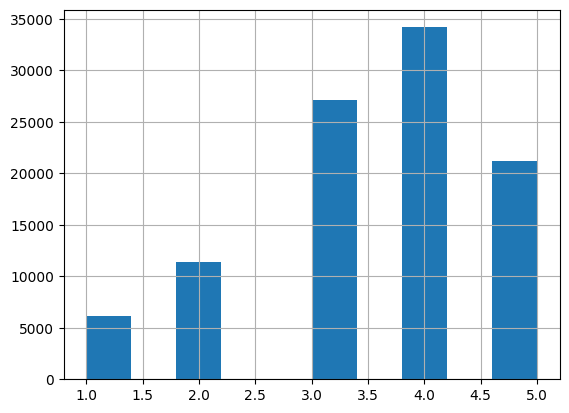

In [12]:
import matplotlib.pyplot as plt

ratings["rating"].hist()
plt.show()

In [13]:
movie_stats = ratings.groupby("movie_id")["rating"].mean()

movie_stats.sort_values(
    ascending=False
).head(10)

movie_id
814     5.0
1599    5.0
1201    5.0
1122    5.0
1653    5.0
1293    5.0
1500    5.0
1189    5.0
1536    5.0
1467    5.0
Name: rating, dtype: float64

In [14]:
## data preprocessing
##label encoding
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

In [15]:
##transform ID's
ratings["user"] = user_encoder.fit_transform(
    ratings["user_id"]
)

ratings["movie"] = movie_encoder.fit_transform(
    ratings["movie_id"]
)

In [16]:
##count users and movies
num_users = ratings["user"].nunique()
num_movies = ratings["movie"].nunique()

print(num_users)
print(num_movies)

943
1682


In [55]:
##train test split
from sklearn.model_selection import train_test_split

X = ratings[["user","movie"]]
y = ratings["rating"] / 5.0

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
##build deep learning model
##import tensorflow
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Flatten,
    Dense,
    Concatenate
)

from tensorflow.keras.models import Model

In [57]:
user_input = Input(shape=(1,), name="user_input")

In [58]:
movie_input = Input(shape=(1,), name="movie_input")

In [59]:
user_embedding = Embedding(
    input_dim=num_users,
    output_dim=50,
    name="user_embedding"
)(user_input)

In [60]:
movie_embedding = Embedding(
    input_dim=num_movies,
    output_dim=50,
    name="movie_embedding"
)(movie_input)

In [61]:
user_vec = Flatten()(user_embedding)
movie_vec = Flatten()(movie_embedding)

In [62]:
x = Concatenate()([user_vec, movie_vec])

In [63]:
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)

output = Dense(1, activation="sigmoid")(x)

In [64]:
model = Model(
    inputs=[user_input, movie_input],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 50)     │     47,150 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 50)     │     84,100 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 50)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 50)        │          0 │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 100)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │     12,928 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 32)        │      2,080 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 1)         │         33 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 154,547 (603.70 KB)

 Trainable params: 154,547 (603.70 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(
    [X_train["user"], X_train["movie"]],
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0398 - mae: 0.1587 - val_loss: 0.0361 - val_mae: 0.1515
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0347 - mae: 0.1472 - val_loss: 0.0351 - val_mae: 0.1477
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0330 - mae: 0.1432 - val_loss: 0.0349 - val_mae: 0.1477
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0306 - mae: 0.1375 - val_loss: 0.0359 - val_mae: 0.1506
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0272 - mae: 0.1293 - val_loss: 0.0361 - val_mae: 0.1492
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0238 - mae: 0.1207 - val_loss: 0.0378 - val_mae: 0.1516
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0209 - mae: 0.1129 - val_loss: 0.0408 - val_mae: 0.1573
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0184 - mae: 0.1059 - val_loss: 0.0424 - val_mae: 0.1591
Epoch 9/10
1000/1000 ━━━━━━━━━━━━━━━━━━━

In [66]:
loss, mae = model.evaluate(
    [X_test["user"], X_test["movie"]],
    y_test
)

print("Test Loss:", loss)
print("Test MAE:", mae)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0446 - mae: 0.1631
Test Loss: 0.04461675137281418
Test MAE: 0.16310866177082062


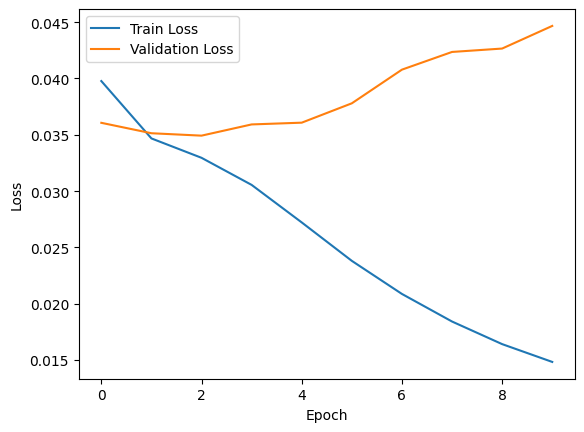

In [67]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [68]:
model.save("../models/movie_recommender.keras")

In [69]:
import pickle

with open("../models/user_encoder.pkl", "wb") as f:
    pickle.dump(user_encoder, f)

with open("../models/movie_encoder.pkl", "wb") as f:
    pickle.dump(movie_encoder, f)

In [70]:
import os
print(os.listdir("../models"))

['.ipynb_checkpoints', 'movie_encoder.pkl', 'movie_recommender.keras', 'user_encoder.pkl']


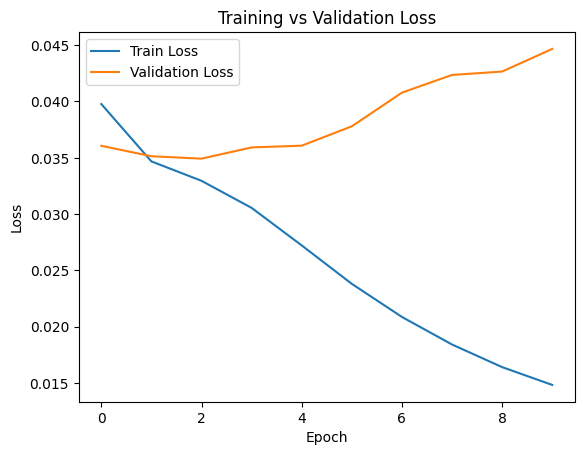

In [71]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [72]:
import pandas as pd
import numpy as np

def recommend_movies(user_id, top_n=10):

    encoded_user = user_encoder.transform([user_id])[0]

    movie_ids = np.arange(num_movies)

    user_array = np.array([encoded_user] * len(movie_ids))

    predictions = model.predict(
        [user_array, movie_ids],
        verbose=0
    ).flatten()

    top_indices = predictions.argsort()[-top_n:][::-1]

    original_movie_ids = movie_encoder.inverse_transform(top_indices)

    recommendations = pd.DataFrame({
        "movie_id": original_movie_ids,
        "predicted_rating": predictions[top_indices]
    })

    recommendations = recommendations.merge(
        movies,
        on="movie_id"
    )

    return recommendations[
        ["title", "predicted_rating"]
    ]

In [73]:
recommend_movies(1)

,title,predicted_rating
0,Pather Panchali (1955),0.975501
1,"Thieves (Voleurs, Les) (1996)",0.972505
2,When We Were Kings (1996),0.972318
3,Paradise Lost: The Child Murders at Robin Hood...,0.971692
4,"Thin Man, The (1934)",0.971369
5,"Usual Suspects, The (1995)",0.971171
6,Paths of Glory (1957),0.970927
7,"Shawshank Redemption, The (1994)",0.969975
8,Chasing Amy (1997),0.969729
9,Hotel de Love (1996),0.969099


In [74]:
movies_full = pd.read_csv(
    "../data/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

print(movies_full.shape)
print(movies_full.head())

(1682, 24)
   0                  1            2   3   \
0   1   Toy Story (1995)  01-Jan-1995 NaN   
1   2   GoldenEye (1995)  01-Jan-1995 NaN   
2   3  Four Rooms (1995)  01-Jan-1995 NaN   
3   4  Get Shorty (1995)  01-Jan-1995 NaN   
4   5     Copycat (1995)  01-Jan-1995 NaN   

                                                  4   5   6   7   8   9   ...  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...   0   0   0   1   1  ...   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...   0   1   1   0   0  ...   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...   0   0   0   0   0  ...   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...   0   1   0   0   0  ...   
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)   0   0   0   0   0  ...   

   14  15  16  17  18  19  20  21  22  23  
0   0   0   0   0   0   0   0   0   0   0  
1   0   0   0   0   0   0   0   1   0   0  
2   0   0   0   0   0   0   0   1   0   0  
3   0   0   0   0   0   0   0   0   0   0  
4   0   0  